In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import LSTMClassifier, TCNClassifier
from src.model.experiment_utils import run_multiclass_distribution_experiment_seq

In [2]:
sequence_length=5

In [3]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [4]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns= list(TRAINGING_CONFIG['target_ranges'].keys())

In [5]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [6]:
param_grid = {
    'model_params.hidden_dim': [64],
    'model_params.num_layers': [4],
    'learning_rate': [0.00001],
    'batch_size': [64],
    'epochs': [5000]
}

In [7]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for standardization
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.fillna(0, inplace=True)

Preparing sequence data for target: home_goals
  X_seq shape: (2280, 5, 2726), y_seq shape: (2280,)
Training LSTMClassifier on home_goals with param grid: {'model_params.hidden_dim': [64], 'model_params.num_layers': [4], 'learning_rate': [1e-05], 'batch_size': [64], 'epochs': [5000]}
Training fold 1/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.9819, LR: 0.000000
Epoch 500/5000, Loss: 1.2751, LR: 0.000010
Epoch 1000/5000, Loss: 0.6019, LR: 0.000010
Epoch 1500/5000, Loss: 0.5135, LR: 0.000010
Epoch 2000/5000, Loss: 0.4549, LR: 0.000010
Epoch 2500/5000, Loss: 0.5004, LR: 0.000010
Epoch 3000/5000, Loss: 0.4680, LR: 0.000010
Epoch 3500/5000, Loss: 0.4929, LR: 0.000010
Epoch 4000/5000, Loss: 0.4620, LR: 0.000010
Epoch 4500/5000, Loss: 0.4423, LR: 0.000010
Epoch 5000/5000, Loss: 0.4289, LR: 0.000010


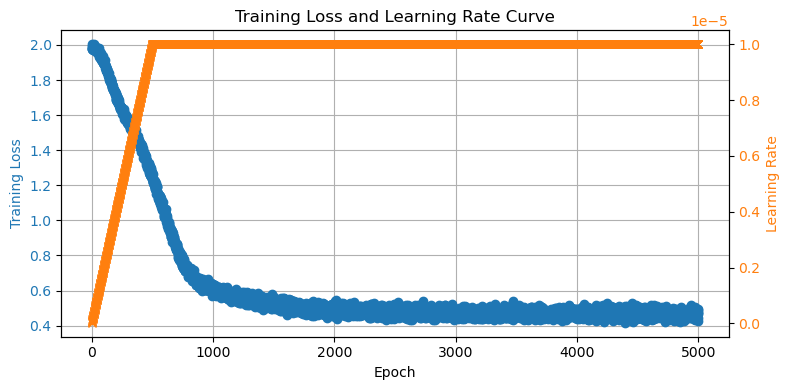

Training fold 2/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0348, LR: 0.000000
Epoch 500/5000, Loss: 1.1132, LR: 0.000010
Epoch 1000/5000, Loss: 0.5695, LR: 0.000010
Epoch 1500/5000, Loss: 0.4686, LR: 0.000010
Epoch 2000/5000, Loss: 0.4534, LR: 0.000010
Epoch 2500/5000, Loss: 0.4617, LR: 0.000010
Epoch 3000/5000, Loss: 0.4577, LR: 0.000010
Epoch 3500/5000, Loss: 0.4502, LR: 0.000010
Epoch 4000/5000, Loss: 0.4474, LR: 0.000010
Epoch 4500/5000, Loss: 0.4508, LR: 0.000010
Epoch 5000/5000, Loss: 0.4488, LR: 0.000010


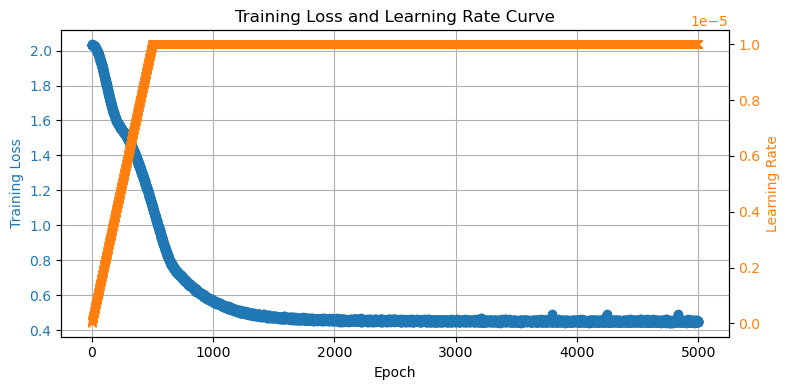

Training fold 3/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3491, LR: 0.000000
Epoch 500/5000, Loss: 0.9568, LR: 0.000010
Epoch 1000/5000, Loss: 0.5265, LR: 0.000010
Epoch 1500/5000, Loss: 0.5151, LR: 0.000010
Epoch 2000/5000, Loss: 0.4388, LR: 0.000010
Epoch 2500/5000, Loss: 0.4317, LR: 0.000010
Epoch 3000/5000, Loss: 0.4280, LR: 0.000010
Epoch 3500/5000, Loss: 0.4330, LR: 0.000010
Epoch 4000/5000, Loss: 0.4735, LR: 0.000010
Epoch 4500/5000, Loss: 0.4574, LR: 0.000010
Epoch 5000/5000, Loss: 0.4335, LR: 0.000010


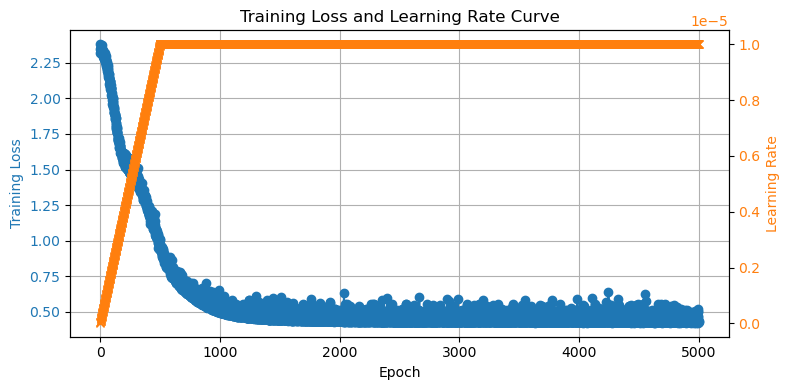

Training fold 4/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.2073, LR: 0.000000
Epoch 500/5000, Loss: 1.0006, LR: 0.000010
Epoch 1000/5000, Loss: 0.5384, LR: 0.000010
Epoch 1500/5000, Loss: 0.4951, LR: 0.000010
Epoch 2000/5000, Loss: 0.4930, LR: 0.000010
Epoch 2500/5000, Loss: 0.4787, LR: 0.000010
Epoch 3000/5000, Loss: 0.4911, LR: 0.000010
Epoch 3500/5000, Loss: 0.4823, LR: 0.000010
Epoch 4000/5000, Loss: 0.4885, LR: 0.000010
Epoch 4500/5000, Loss: 0.4774, LR: 0.000010
Epoch 5000/5000, Loss: 0.4901, LR: 0.000010


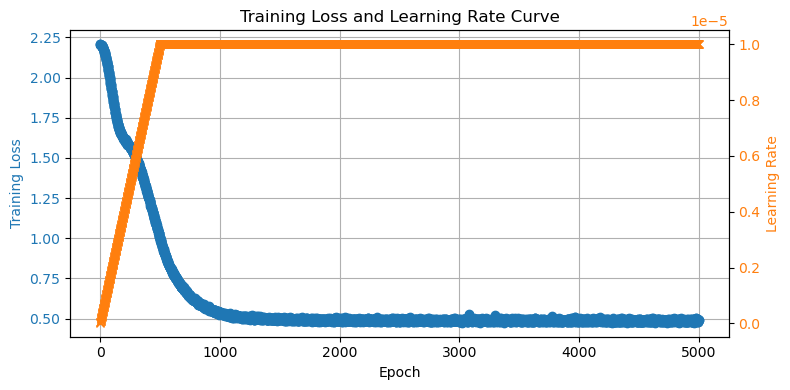

Training fold 5/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.4985, LR: 0.000000
Epoch 500/5000, Loss: 0.9343, LR: 0.000010
Epoch 1000/5000, Loss: 0.5262, LR: 0.000010
Epoch 1500/5000, Loss: 0.4988, LR: 0.000010
Epoch 2000/5000, Loss: 0.4930, LR: 0.000010
Epoch 2500/5000, Loss: 0.4939, LR: 0.000010
Epoch 3000/5000, Loss: 0.4941, LR: 0.000010
Epoch 3500/5000, Loss: 0.4943, LR: 0.000010
Epoch 4000/5000, Loss: 0.4918, LR: 0.000010
Epoch 4500/5000, Loss: 0.4903, LR: 0.000010
Epoch 5000/5000, Loss: 0.4942, LR: 0.000010


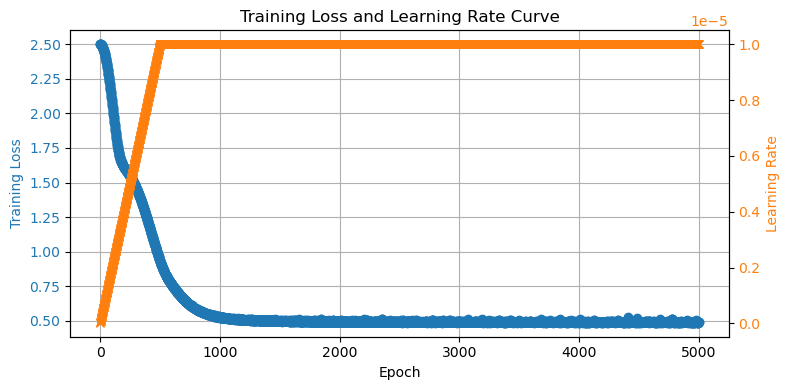

Preparing sequence data for target: away_goals
  X_seq shape: (2280, 5, 2726), y_seq shape: (2280,)
Training LSTMClassifier on away_goals with param grid: {'model_params.hidden_dim': [64], 'model_params.num_layers': [4], 'learning_rate': [1e-05], 'batch_size': [64], 'epochs': [5000]}
Training fold 1/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.7326, LR: 0.000000
Epoch 500/5000, Loss: 1.1612, LR: 0.000010
Epoch 1000/5000, Loss: 0.5377, LR: 0.000010
Epoch 1500/5000, Loss: 0.4226, LR: 0.000010
Epoch 2000/5000, Loss: 0.4298, LR: 0.000010
Epoch 2500/5000, Loss: 0.3846, LR: 0.000010
Epoch 3000/5000, Loss: 0.4113, LR: 0.000010
Epoch 3500/5000, Loss: 0.3888, LR: 0.000010
Epoch 4000/5000, Loss: 0.3965, LR: 0.000010
Epoch 4500/5000, Loss: 0.4036, LR: 0.000010
Epoch 5000/5000, Loss: 0.4167, LR: 0.000010


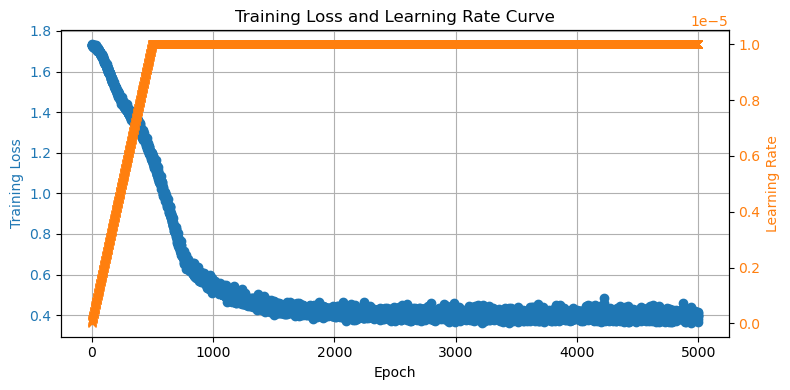

Training fold 2/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.9136, LR: 0.000000
Epoch 500/5000, Loss: 1.0738, LR: 0.000010
Epoch 1000/5000, Loss: 0.5477, LR: 0.000010
Epoch 1500/5000, Loss: 0.4618, LR: 0.000010
Epoch 2000/5000, Loss: 0.4466, LR: 0.000010
Epoch 2500/5000, Loss: 0.4444, LR: 0.000010
Epoch 3000/5000, Loss: 0.4445, LR: 0.000010
Epoch 3500/5000, Loss: 0.4497, LR: 0.000010
Epoch 4000/5000, Loss: 0.4427, LR: 0.000010
Epoch 4500/5000, Loss: 0.4494, LR: 0.000010
Epoch 5000/5000, Loss: 0.4473, LR: 0.000010


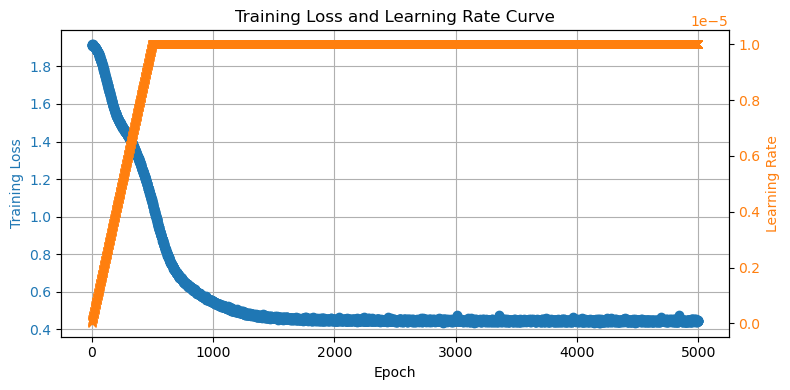

Training fold 3/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.5963, LR: 0.000000
Epoch 500/5000, Loss: 0.8991, LR: 0.000010
Epoch 1000/5000, Loss: 0.6348, LR: 0.000010
Epoch 1500/5000, Loss: 0.4459, LR: 0.000010
Epoch 2000/5000, Loss: 0.4389, LR: 0.000010
Epoch 2500/5000, Loss: 0.4325, LR: 0.000010
Epoch 3000/5000, Loss: 0.4341, LR: 0.000010
Epoch 3500/5000, Loss: 0.4355, LR: 0.000010
Epoch 4000/5000, Loss: 0.4363, LR: 0.000010
Epoch 4500/5000, Loss: 0.4647, LR: 0.000010
Epoch 5000/5000, Loss: 0.4331, LR: 0.000010


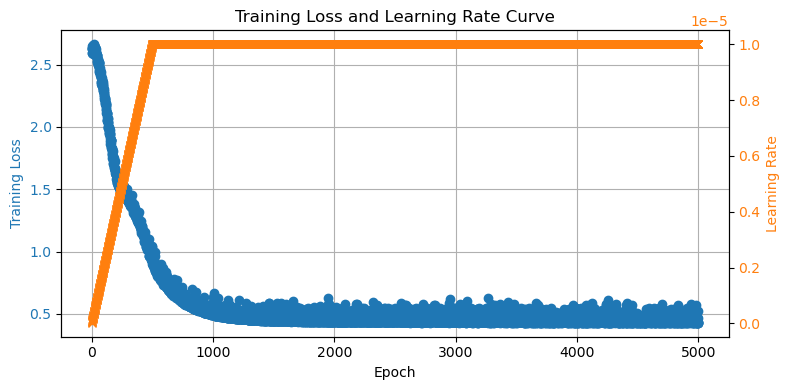

Training fold 4/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1989, LR: 0.000000
Epoch 500/5000, Loss: 0.8462, LR: 0.000010
Epoch 1000/5000, Loss: 0.4855, LR: 0.000010
Epoch 1500/5000, Loss: 0.4725, LR: 0.000010
Epoch 2000/5000, Loss: 0.4553, LR: 0.000010
Epoch 2500/5000, Loss: 0.4597, LR: 0.000010
Epoch 3000/5000, Loss: 0.4686, LR: 0.000010
Epoch 3500/5000, Loss: 0.4602, LR: 0.000010
Epoch 4000/5000, Loss: 0.4523, LR: 0.000010
Epoch 4500/5000, Loss: 0.4529, LR: 0.000010
Epoch 5000/5000, Loss: 0.4581, LR: 0.000010


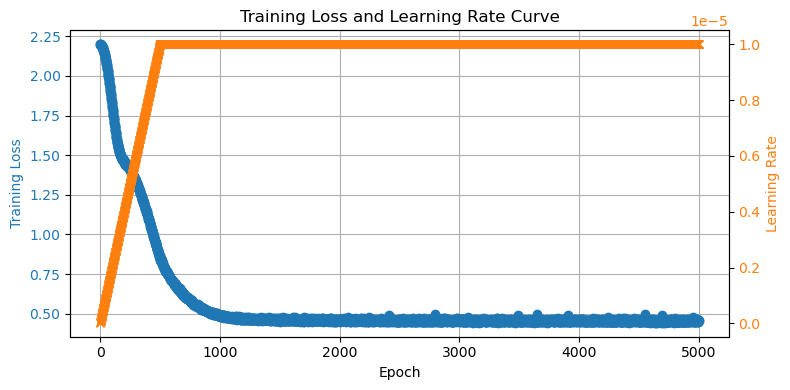

Training fold 5/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3386, LR: 0.000000
Epoch 500/5000, Loss: 0.8192, LR: 0.000010
Epoch 1000/5000, Loss: 0.4795, LR: 0.000010
Epoch 1500/5000, Loss: 0.4632, LR: 0.000010
Epoch 2000/5000, Loss: 0.4579, LR: 0.000010
Epoch 2500/5000, Loss: 0.4573, LR: 0.000010
Epoch 3000/5000, Loss: 0.4518, LR: 0.000010
Epoch 3500/5000, Loss: 0.4519, LR: 0.000010
Epoch 4000/5000, Loss: 0.4521, LR: 0.000010
Epoch 4500/5000, Loss: 0.4542, LR: 0.000010
Epoch 5000/5000, Loss: 0.4551, LR: 0.000010


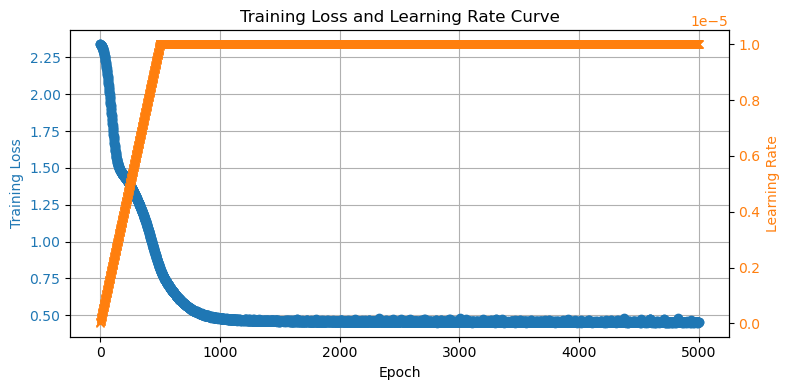

{('home_goals',
  "{'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}"): {'accuracy': 0.2742690058479532,
  'precision': 0.13889944809618643,
  'home_goals_lte_0_accuracy': 0.2076512434933488,
  'home_goals_lte_0_accuracy_std': 0.04415815586069947,
  'home_goals_lte_0_precision': 0.21000000000000002,
  'home_goals_lte_0_precision_std': 0.019999999999999997,
  'home_goals_gt_0_accuracy': 0.3005747760892562,
  'home_goals_gt_0_accuracy_std': 0.05648364402054406,
  'home_goals_gt_0_precision': 0.13420382424560653,
  'home_goals_gt_0_precision_std': 0.029113067457268035,
  'home_goals_lte_1_accuracy': 0.3711783273130733,
  'home_goals_lte_1_accuracy_std': 0.0698899610012591,
  'home_goals_lte_1_precision': 0.18347035789215935,
  'home_goals_lte_1_precision_std': 0.026714177588751817,
  'home_goals_gt_1_accuracy': 0.1584664974238675,
  'home_goals_gt_1_accuracy_std': 0.08026270939263025,
  'home_goals_gt_1_precision': 0.12

In [9]:
run_multiclass_distribution_experiment_seq(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchSequenceWrapper(
        model_class=LSTMClassifier,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='LSTMClassifier',
    key_columns=TRAINGING_CONFIG['key_columns'],
    sequence_length=5
)